# 01: MFCAD++ Data Exploration

Comprehensive exploration of the MFCAD++ hierarchical B-Rep graph dataset.

**Sections:**
1. Setup & dataset loading
2. Dataset statistics
3. Label distribution
4. B-Rep graph visualizations
5. Node feature statistics
6. Edge convexity distribution

## 1. Setup & Dataset Loading

In [1]:
import os
import sys
import glob
from pathlib import Path


def find_project_root(start: Path) -> Path:
    candidates = [
        start,
        *start.parents,
        start / "hanomi-repo",
        Path("/kaggle/working/hanomi-repo"),
        Path("/kaggle/input/hanomi-feature-repo"),
    ]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import networkx as nx
    from torch_geometric.utils import to_networkx
    from src.data.h5_dataset import MFCADPlusPlusDataset, LABEL_NAMES
    HAS_DEPS = True
except ImportError as exc:
    HAS_DEPS = False
    MISSING = str(exc)

if HAS_DEPS:
    print('All dependencies available.')
else:
    print(f'Missing dependency: {MISSING}')
    print('Install with:  pip install torch torch-geometric networkx h5py matplotlib')

All dependencies available.


In [2]:
CANDIDATE_PATHS = [
    "/Users/anmolsen/Developer/MFCAD++_dataset/hierarchical_graphs/test_MFCAD++.h5",
    os.path.join(PROJECT_ROOT, 'MFCAD++_dataset', 'hierarchical_graphs', 'test_MFCAD++.h5'),
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'test_MFCAD++.h5'),
]

KAGGLE_GLOB = '/kaggle/input/**/test_MFCAD++.h5'
    

def _find_h5():
    for p in CANDIDATE_PATHS:
        if os.path.isfile(p):
            return p
    for p in glob.glob(KAGGLE_GLOB, recursive=True):
        if os.path.isfile(p):
            return p
    return None


dataset = None

if not HAS_DEPS:
    print('Skipping dataset load (missing dependencies).')
else:
    h5_path = _find_h5()
    if h5_path is None:
        print('Dataset not found. Searched:')
        for p in CANDIDATE_PATHS:
            print(f'  {p}')
        print(f'  {KAGGLE_GLOB}')
        print()
        print('Download the MFCAD++ dataset and place test_MFCAD++.h5 at one of the paths above.')
        print('See README for setup instructions.')
    else:
        print(f'Loading: {h5_path}')
        dataset = MFCADPlusPlusDataset(h5_path)
        print(f'Dataset loaded: {len(dataset)} models')

DATASET_AVAILABLE = dataset is not None

Loading: /Users/anmolsen/Developer/MFCAD++_dataset/hierarchical_graphs/test_MFCAD++.h5
Dataset loaded: 8632 models


## 2. Dataset Statistics

Number of models : 8632
Total faces      : 258382
Faces per model:
  min  = 3
  max  = 72
  mean = 29.9
  med  = 29.0


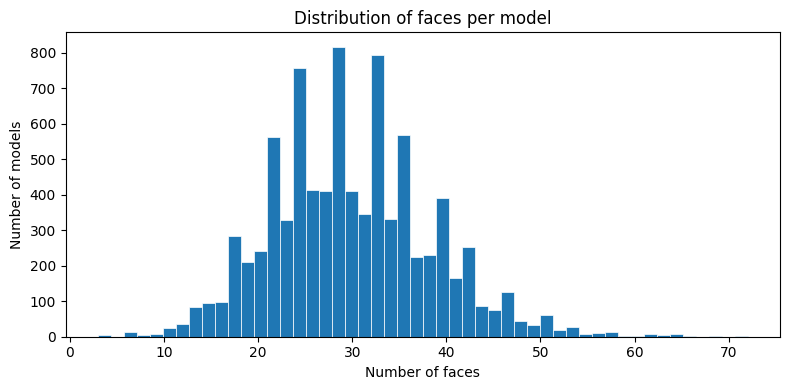

In [3]:
if not DATASET_AVAILABLE:
    print('Dataset not loaded — skipping statistics.')
else:
    n_models = len(dataset)
    faces_per_model = [dataset[i].num_nodes for i in range(n_models)]
    total_faces = sum(faces_per_model)

    print(f'Number of models : {n_models}')
    print(f'Total faces      : {total_faces}')
    print(f'Faces per model:')
    print(f'  min  = {np.min(faces_per_model)}')
    print(f'  max  = {np.max(faces_per_model)}')
    print(f'  mean = {np.mean(faces_per_model):.1f}')
    print(f'  med  = {np.median(faces_per_model):.1f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(faces_per_model, bins=50, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Number of faces')
    ax.set_ylabel('Number of models')
    ax.set_title('Distribution of faces per model')
    fig.tight_layout()
    plt.show()

## 3. Label Distribution

Total labelled faces: 258,382
Unique labels      : 25


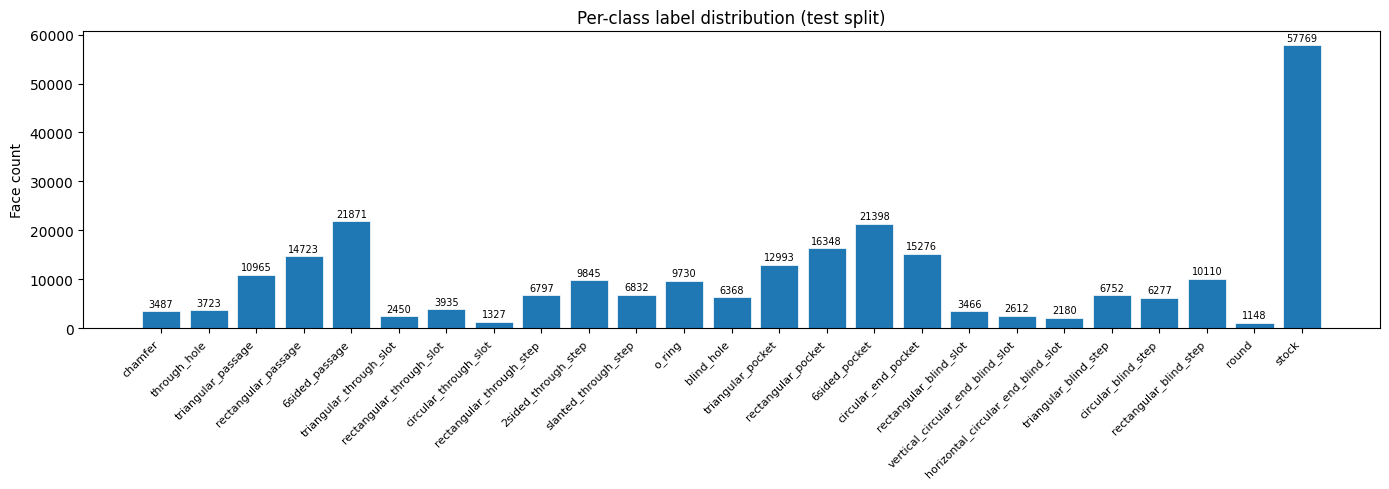

In [4]:
if not DATASET_AVAILABLE:
    print('Dataset not loaded — skipping label distribution.')
else:
    dist = dataset.label_distribution()
    names = list(dist.keys())
    counts = list(dist.values())

    total_labelled = sum(counts)
    print(f'Total labelled faces: {total_labelled:,}')
    print(f'Unique labels      : {len(names)}')

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(names)), counts, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Face count')
    ax.set_title('Per-class label distribution (test split)')

    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_labelled * 0.002,
                str(cnt), ha='center', va='bottom', fontsize=7)

    fig.tight_layout()
    plt.show()

## 4. B-Rep Graph Visualizations

Each node represents a B-Rep face, colored by its segmentation label.
Edges represent shared boundaries between faces.

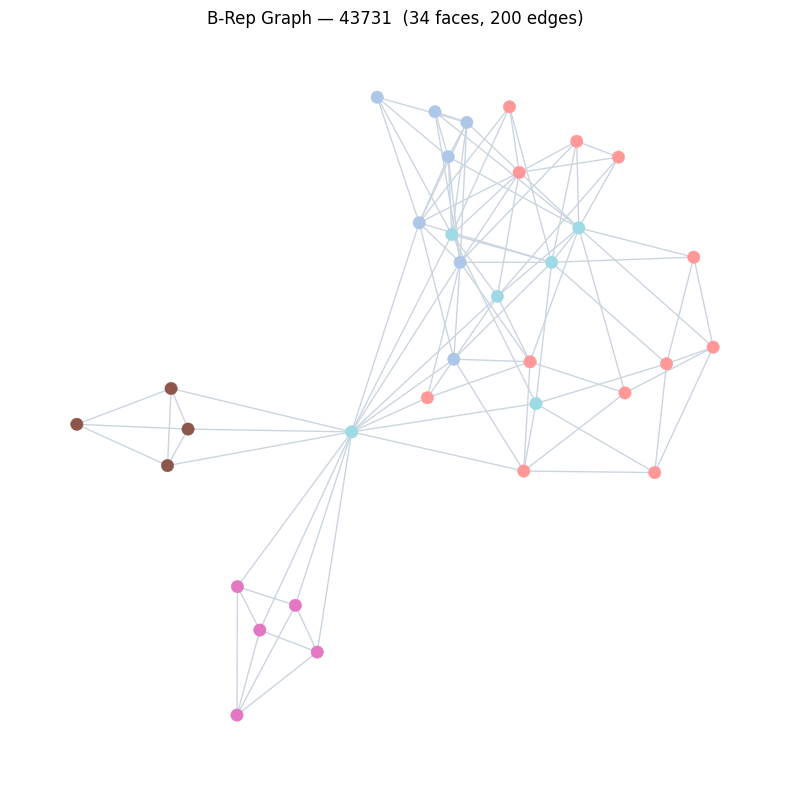

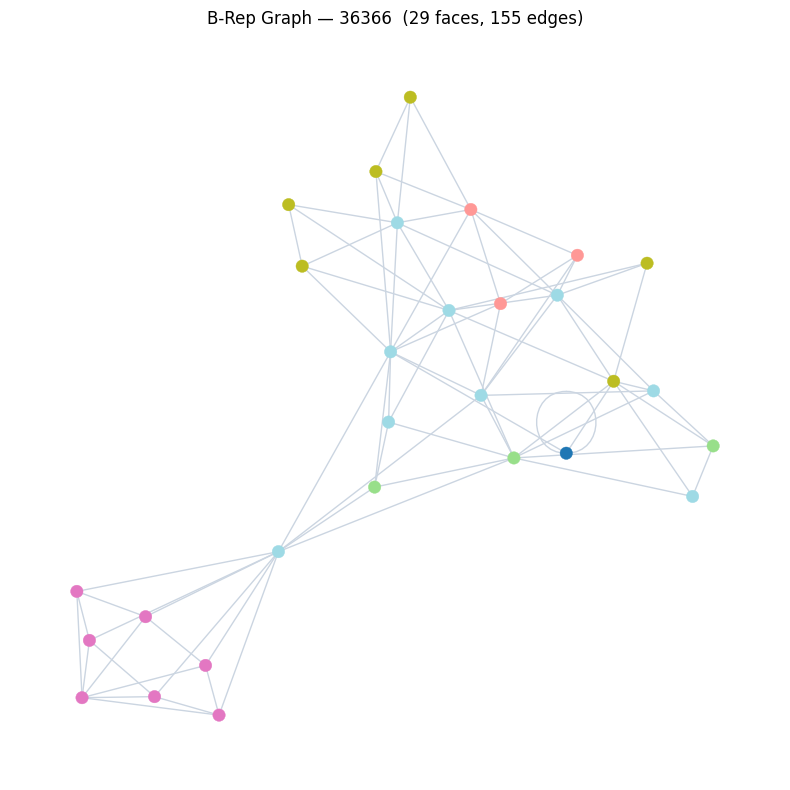

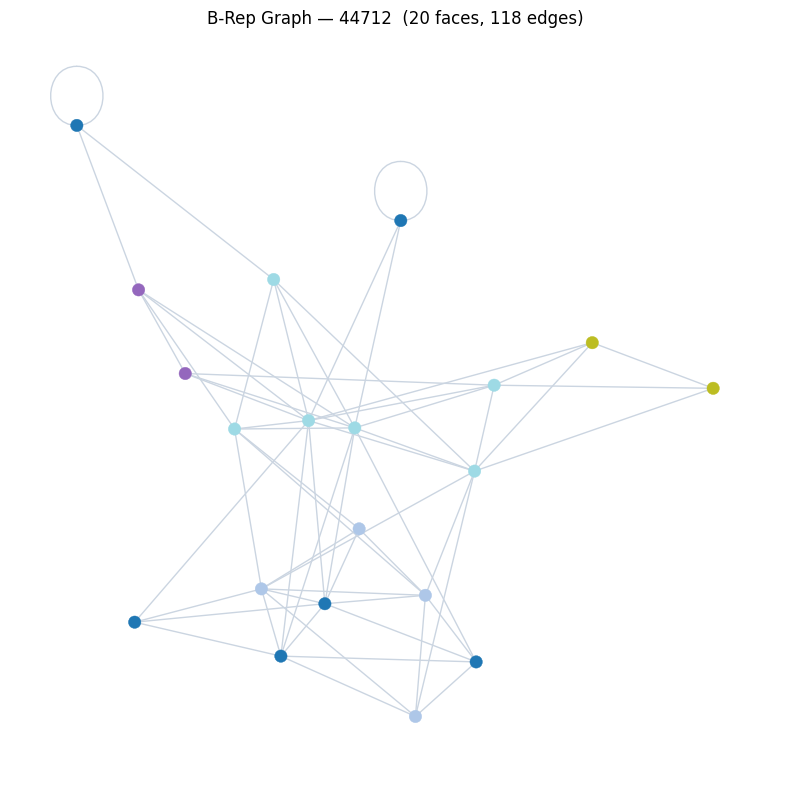

In [5]:
N_VIS = 3
SEED = 42

if not DATASET_AVAILABLE:
    print('Dataset not loaded — skipping graph visualizations.')
else:
    rng = np.random.default_rng(SEED)
    vis_indices = rng.choice(len(dataset), size=min(N_VIS, len(dataset)), replace=False)

    cmap = plt.cm.tab20
    n_labels = len(LABEL_NAMES)

    for idx in vis_indices:
        data = dataset[int(idx)]
        G = to_networkx(data, to_undirected=True)
        labels = data.y.numpy()
        node_colors = [cmap(l / n_labels) for l in labels]

        fig, ax = plt.subplots(figsize=(8, 8))
        pos = nx.spring_layout(G, seed=SEED)
        nx.draw_networkx(
            G,
            pos=pos,
            node_size=80,
            node_color=node_colors,
            edge_color='#CBD5E1',
            linewidths=0.3,
            with_labels=False,
            ax=ax,
        )
        model_id = getattr(data, 'model_id', f'model_{idx}')
        ax.set_title(f'B-Rep Graph — {model_id}  ({data.num_nodes} faces, {data.edge_index.size(1)} edges)')
        ax.axis('off')
        fig.tight_layout()
        plt.show()

### Legend for graph node colors

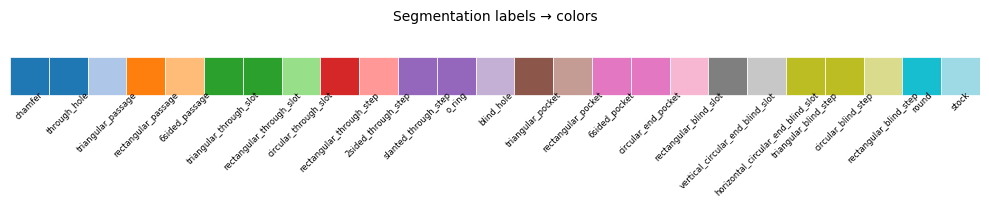

In [6]:
if DATASET_AVAILABLE:
    fig, ax = plt.subplots(figsize=(10, 2))
    for i, (label_id, label_name) in enumerate(sorted(LABEL_NAMES.items())):
        color = cmap(label_id / n_labels)
        ax.barh(0, 1, left=i, color=color, edgecolor='white', linewidth=0.5)
        ax.text(i + 0.5, -0.3, label_name, ha='center', va='top', fontsize=6, rotation=45)
    ax.set_xlim(0, n_labels)
    ax.set_ylim(-1.5, 1)
    ax.axis('off')
    ax.set_title('Segmentation labels → colors', fontsize=10)
    fig.tight_layout()
    plt.show()

## 5. Node Feature Statistics

Node features are 8-dimensional:
`[area, cx, cy, cz, surface_type, degree, n_convex, n_concave]`

In [7]:
NODE_FEAT_NAMES = ['area', 'cx', 'cy', 'cz', 'surface_type', 'degree', 'n_convex', 'n_concave']

if not DATASET_AVAILABLE:
    print('Dataset not loaded — skipping node feature statistics.')
else:
    all_x = torch.cat([dataset[i].x for i in range(len(dataset))], dim=0).numpy()
    print(f'Stacked node feature matrix: {all_x.shape}\n')

    print(f'{"Feature":<18} {"Min":>12} {"Max":>12} {"Mean":>12} {"Std":>12}')
    print('-' * 68)
    for j, name in enumerate(NODE_FEAT_NAMES):
        col = all_x[:, j]
        print(f'{name:<18} {col.min():>12.4f} {col.max():>12.4f} {col.mean():>12.4f} {col.std():>12.4f}')

Stacked node feature matrix: (258382, 8)

Feature                     Min          Max         Mean          Std
--------------------------------------------------------------------
area                     0.0000       1.0000       0.1827       0.2681
cx                      -0.0000       1.0000       0.4977       0.2786
cy                       0.0000       1.0000       0.4981       0.2795
cz                       0.0000       1.0000       0.4991       0.2786
surface_type             0.0909       0.7273       0.1012       0.0334
degree                   1.0000      45.0000       5.1500       2.9913
n_convex                 0.0000      44.0000       3.4539       3.6188
n_concave                0.0000      15.0000       1.6081       1.2416


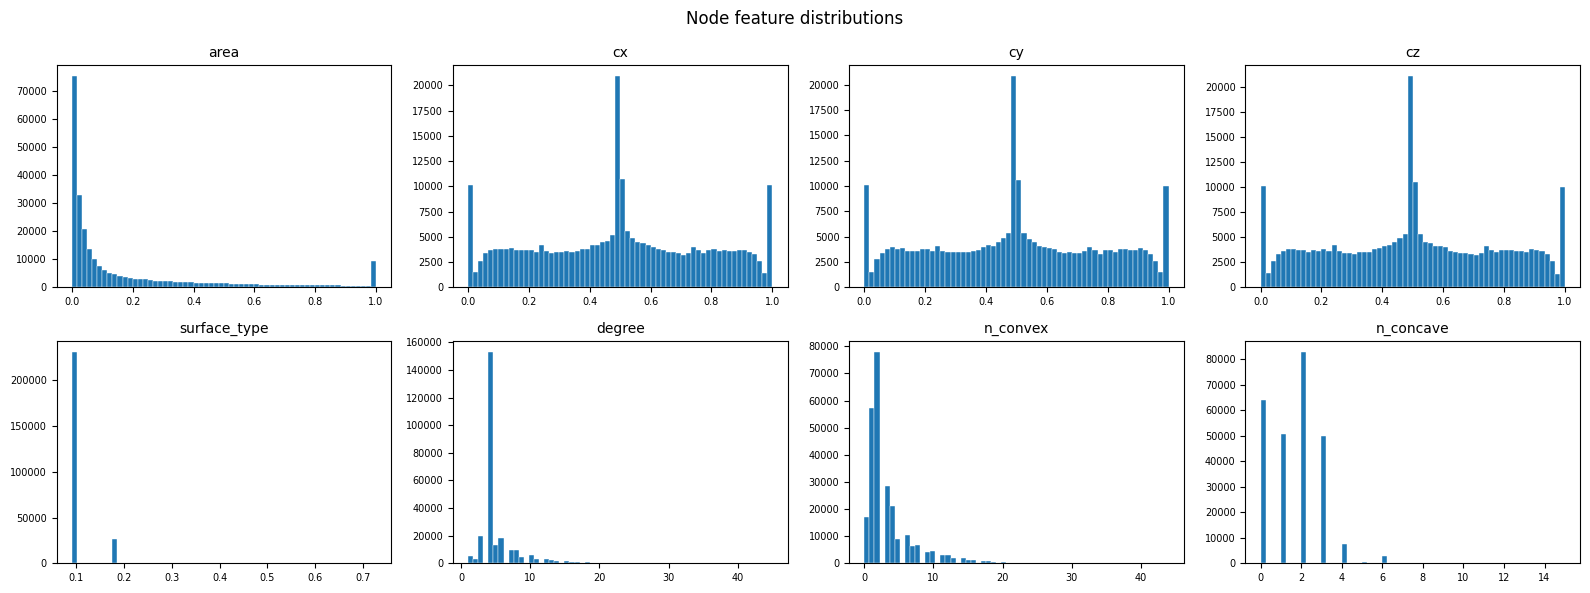

In [8]:
if DATASET_AVAILABLE:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for j, (ax, name) in enumerate(zip(axes.flat, NODE_FEAT_NAMES)):
        ax.hist(all_x[:, j], bins=60, edgecolor='white', linewidth=0.3)
        ax.set_title(name, fontsize=10)
        ax.tick_params(labelsize=7)
    fig.suptitle('Node feature distributions', fontsize=12)
    fig.tight_layout()
    plt.show()

## 6. Edge Convexity Distribution

Edge attributes are 3-dimensional:
`[convexity ∈ {-1, 0, 1}, is_convex ∈ {0,1}, is_concave ∈ {0,1}]`

Total edges : 1,330,675
  Convex    :  892,434  (67.1%)
  Concave   :  415,510  (31.2%)
  Smooth    :   22,731  (1.7%)


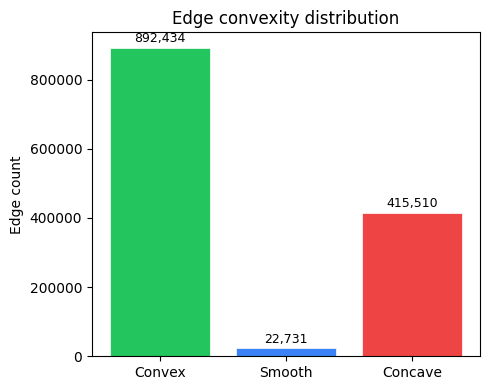

In [9]:
if not DATASET_AVAILABLE:
    print('Dataset not loaded — skipping edge statistics.')
else:
    all_ea = torch.cat([dataset[i].edge_attr for i in range(len(dataset))], dim=0).numpy()

    n_convex  = int((all_ea[:, 1] > 0.5).sum())
    n_concave = int((all_ea[:, 2] > 0.5).sum())
    n_smooth  = len(all_ea) - n_convex - n_concave
    total_e   = len(all_ea)

    print(f'Total edges : {total_e:,}')
    print(f'  Convex    : {n_convex:>8,}  ({100 * n_convex / total_e:.1f}%)')
    print(f'  Concave   : {n_concave:>8,}  ({100 * n_concave / total_e:.1f}%)')
    print(f'  Smooth    : {n_smooth:>8,}  ({100 * n_smooth / total_e:.1f}%)')

    fig, ax = plt.subplots(figsize=(5, 4))
    categories = ['Convex', 'Smooth', 'Concave']
    values = [n_convex, n_smooth, n_concave]
    colors = ['#22C55E', '#3B82F6', '#EF4444']
    bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_e * 0.005,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Edge count')
    ax.set_title('Edge convexity distribution')
    fig.tight_layout()
    plt.show()